In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'placement_predict_50k Dataset (1).csv',
 'WineQT.csv',
 'weather_cricket.csv']

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1143
Number of columns: 13


In [ ]:
df.shape

(1143, 13)

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')

# 1. Dataset size
print("Number of samples:", df.shape[0])
print("Number of columns:", df.shape[1])

# 2. First 5 rows
print("\nFirst 5 rows:")
display(df.head())

# 3. Column names
print("\nColumn names:")
print(df.columns.tolist())

# 4. Data types
print("\nData types:")
print(df.dtypes)

# 5. Missing values
print("\nMissing values:")
print(df.isnull().sum())

# 6. Statistical summary
print("\nStatistical summary:")
display(df.describe())

Number of samples: 1143
Number of columns: 13

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


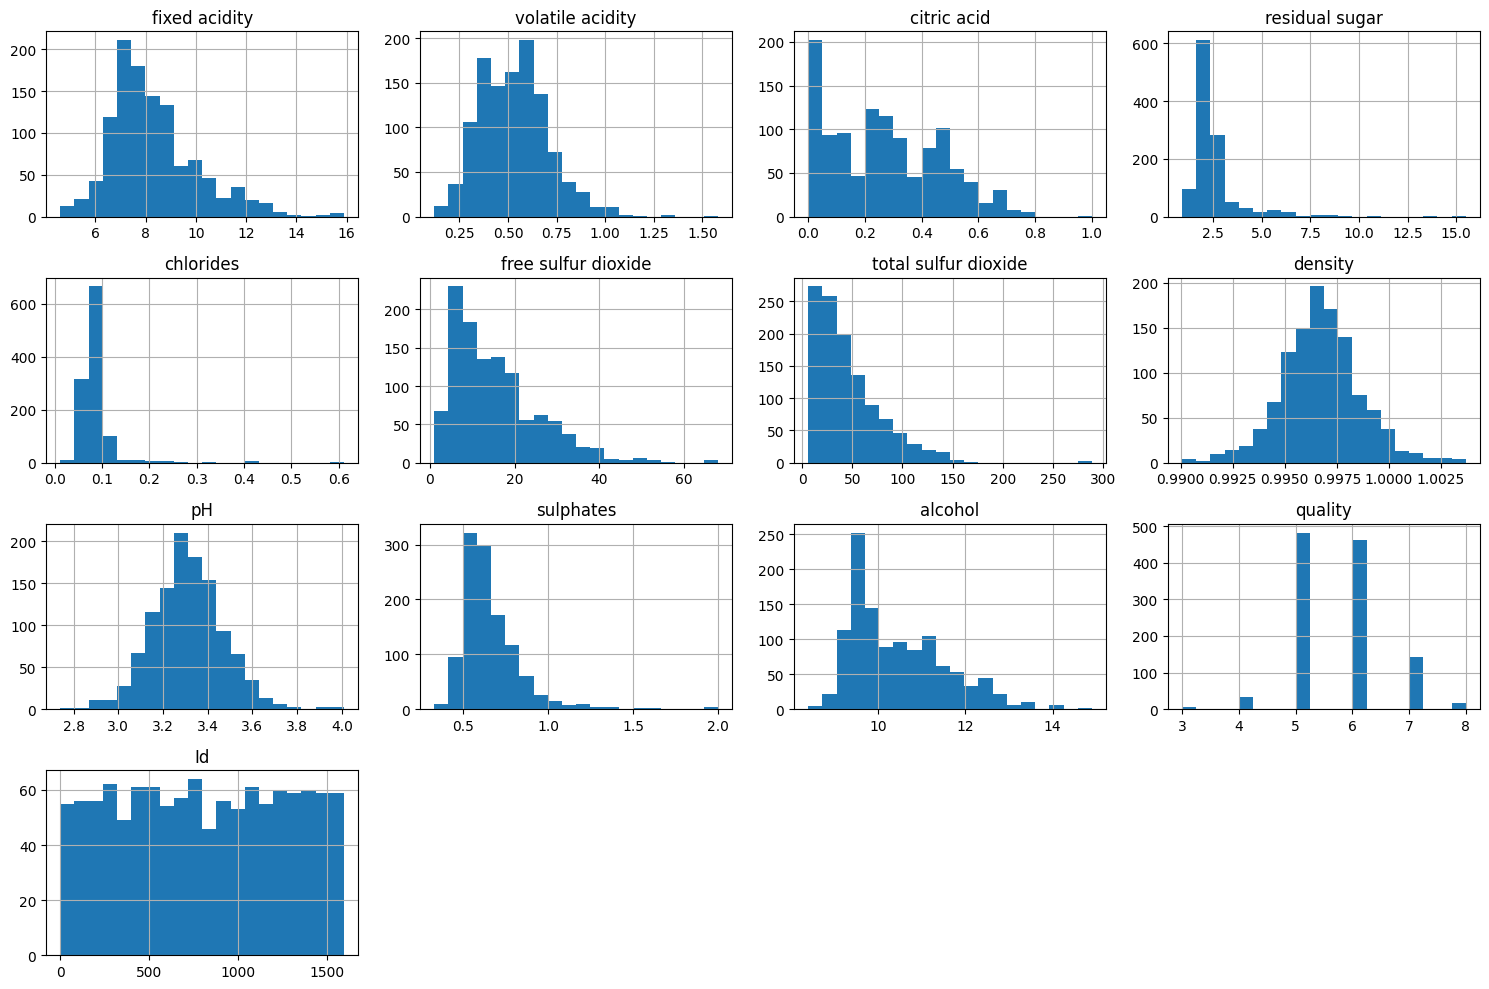

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


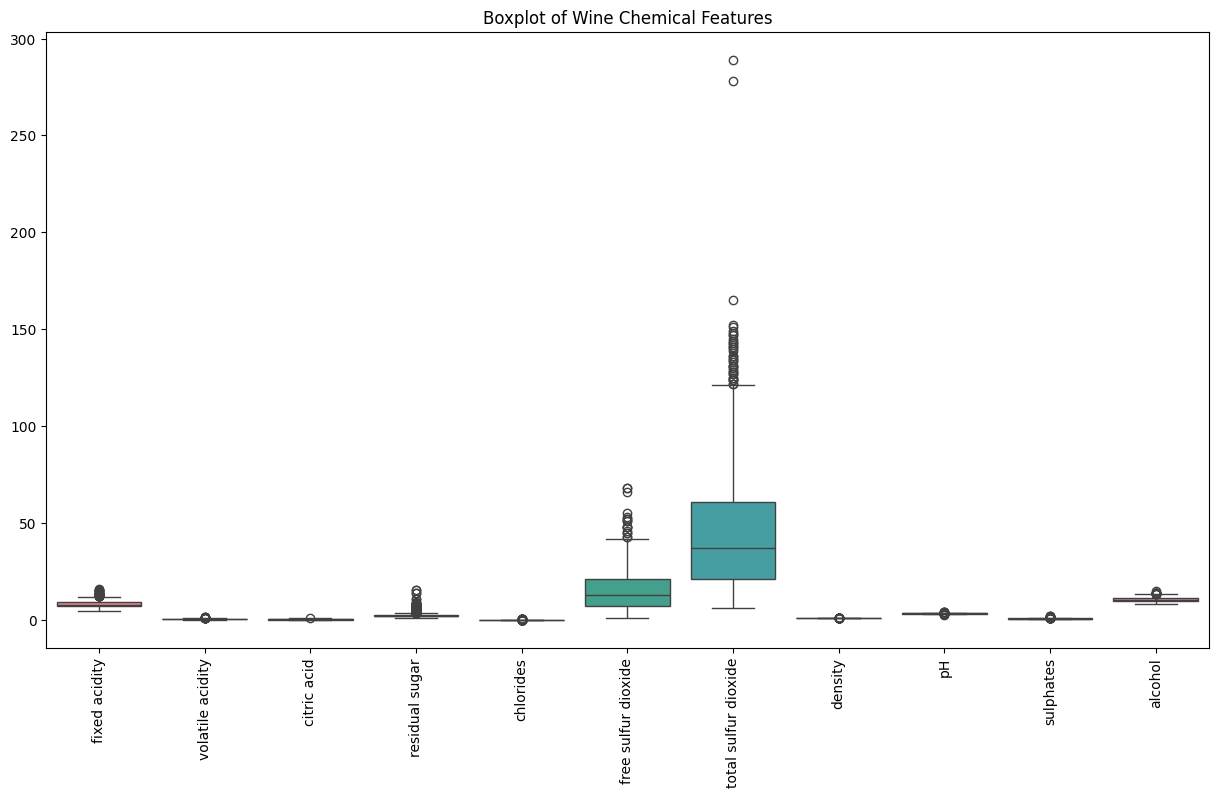

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = df.drop(columns=['Id', 'quality'])

plt.figure(figsize=(15, 8))
sns.boxplot(data=features)
plt.xticks(rotation=90)
plt.title("Boxplot of Wine Chemical Features")
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 1. Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')

# 2. Select the 11 chemical features
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[features]

# 3. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization completed!")
print("Shape of X_scaled:", X_scaled.shape)

# 4. Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# 5. Count clusters and anomalies
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_anomalies = (labels == -1).sum()

print("Number of clusters:", n_clusters)
print("Number of anomalies:", n_anomalies)

# 6. Calculate Silhouette Score
# Exclude DBSCAN noise/anomaly points (-1)
mask = labels != -1

if len(set(labels[mask])) >= 2:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated because fewer than 2 clusters remain.")

Standardization completed!
Shape of X_scaled: (1143, 11)
Number of clusters: 1
Number of anomalies: 1135
Silhouette Score cannot be calculated because fewer than 2 clusters remain.


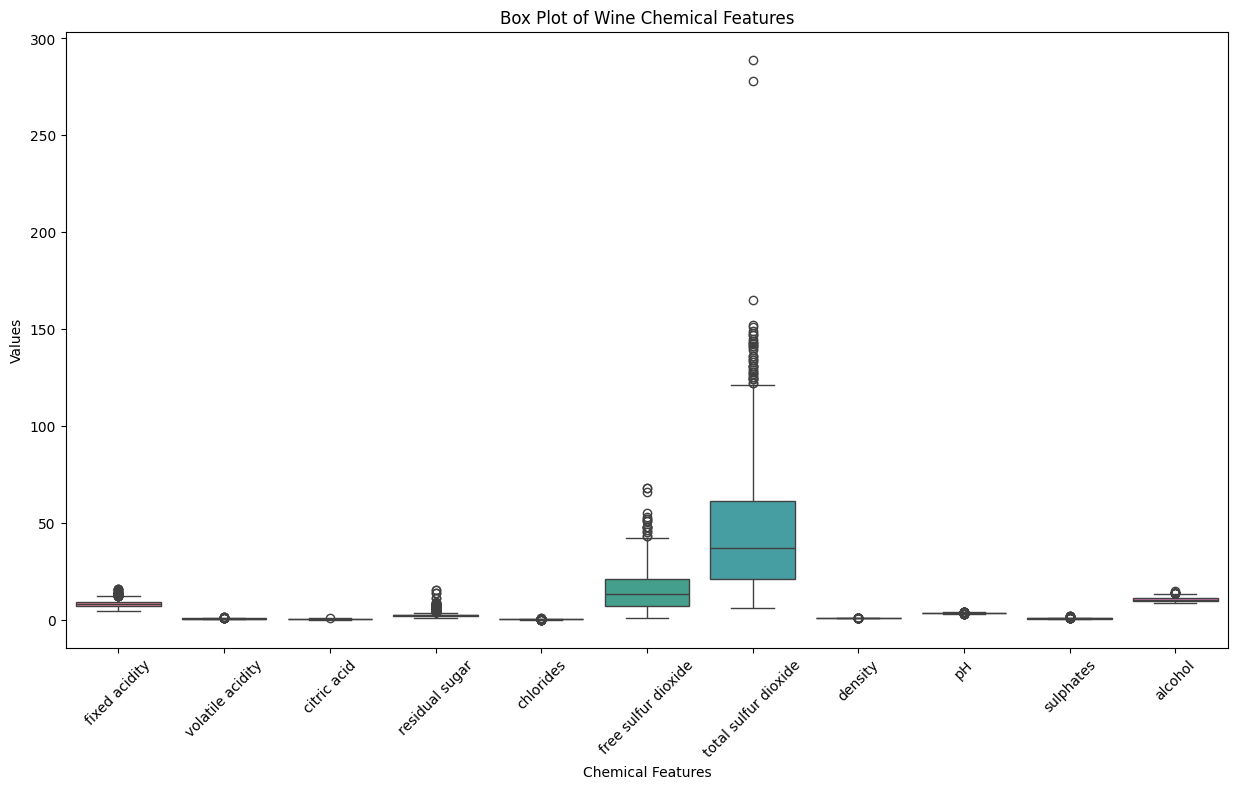

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')

# Select only the 11 chemical features
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

# Create box plot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[features])

plt.title("Box Plot of Wine Chemical Features")
plt.xlabel("Chemical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')

# Select 11 chemical features
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

# Calculate Q1, Q3 and IQR
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Find outliers
outliers = (
    (df[features] < Q1 - 1.5 * IQR) |
    (df[features] > Q3 + 1.5 * IQR)
)

# Count outliers in each feature
print("Number of outliers in each feature:")
print(outliers.sum())

# Total rows containing at least one outlier
print("\nTotal samples containing at least one outlier:",
      outliers.any(axis=1).sum())

Number of outliers in each feature:
fixed acidity            44
volatile acidity         14
citric acid               1
residual sugar          110
chlorides                77
free sulfur dioxide      18
total sulfur dioxide     40
density                  36
pH                       20
sulphates                43
alcohol                  12
dtype: int64

Total samples containing at least one outlier: 295


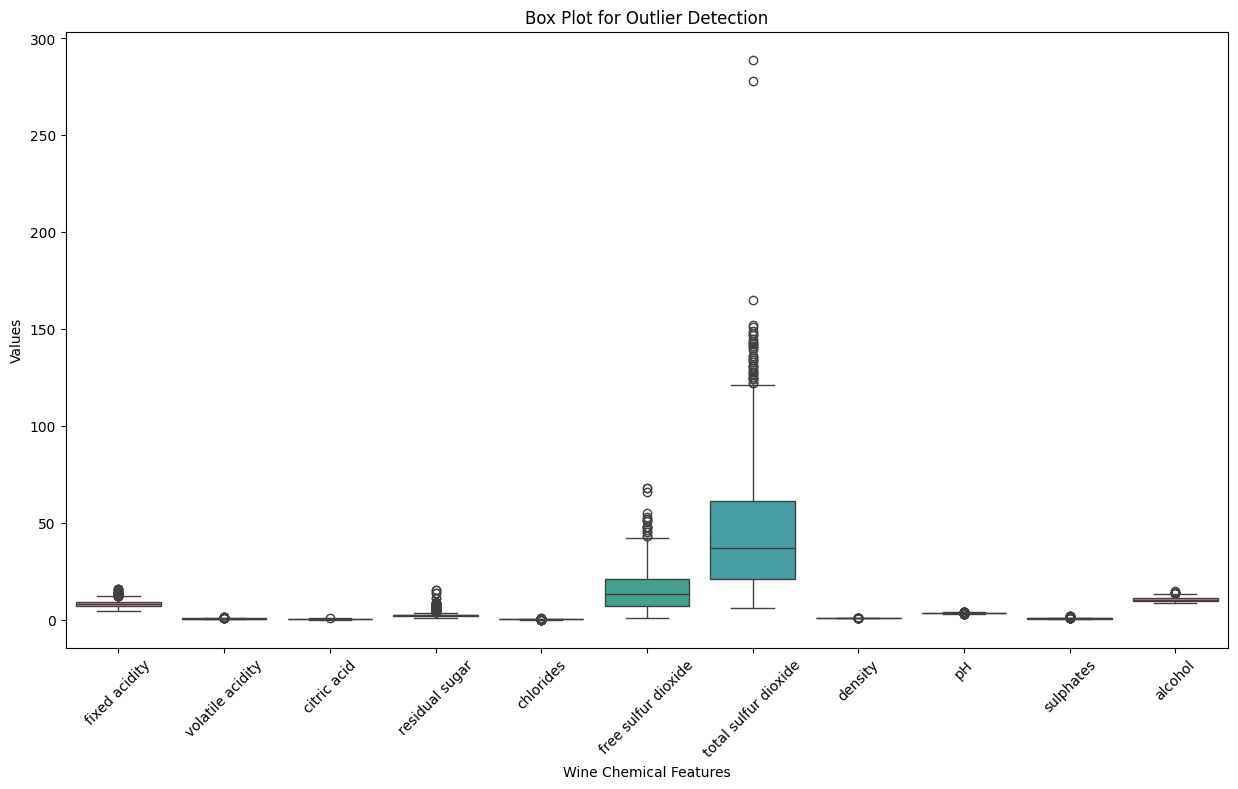

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[features])

plt.title("Box Plot for Outlier Detection")
plt.xlabel("Wine Chemical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()